🌍 网格尺寸: 180 x 80 x 40
✅ 地形数据加载成功，形状: (80, 180)
✅ 加载了 1048 条河流数据
✅ 初始场生成完成，非零数量: 8869
✅ 河口(31.50,122.00) → 投影(55,61) 偏移 0.00 格点
✅ 河口(29.40,94.50) → 投影(50,45) 偏移 4.47 格点
✅ 河口(22.00,88.00) → 投影(50,44) 偏移 0.00 格点
✅ 河口(9.00,78.10) → 投影(44,39) 偏移 0.00 格点
✅ 河口(-1.00,-51.20) → 投影(39,0) 偏移 0.00 格点
✅ 河口(-6.20,106.90) → 投影(36,53) 偏移 0.00 格点
✅ 河口(9.30,78.10) → 投影(44,39) 偏移 0.00 格点
✅ 河口(9.30,105.00) → 投影(44,52) 偏移 0.00 格点
✅ 河口(16.50,96.10) → 投影(48,47) 偏移 1.00 格点
✅ 河口(-6.00,12.30) → 投影(37,5) 偏移 1.00 格点
✅ 河口(10.40,-74.70) → 投影(43,1) 偏移 2.24 格点
✅ 河口(22.80,113.60) → 投影(50,57) 偏移 1.00 格点
✅ 河口(-34.60,-58.40) → 投影(22,0) 偏移 0.00 格点
✅ 河口(22.00,90.50) → 投影(50,45) 偏移 0.00 格点
✅ 河口(30.50,48.20) → 投影(52,28) 偏移 5.00 格点
✅ 河口(8.50,-62.00) → 投影(43,1) 偏移 1.41 格点
✅ 河口(51.90,4.00) → 投影(66,2) 偏移 1.00 格点
✅ 河口(11.00,122.70) → 投影(45,61) 偏移 0.00 格点
✅ 河口(53.30,140.80) → 投影(67,70) 偏移 1.00 格点
⚠️ 河口(46.70, 47.70) 在 10 格点内无海洋，跳过
⚠️ 河口(45.20, 29.60) 在 10 格点内无海洋，跳过
⚠️ 河口(29.20, -89.30) 在 10 格点内无海洋，跳过
✅ 河口(6.40,3.40) → 投影(43,1) 偏移 

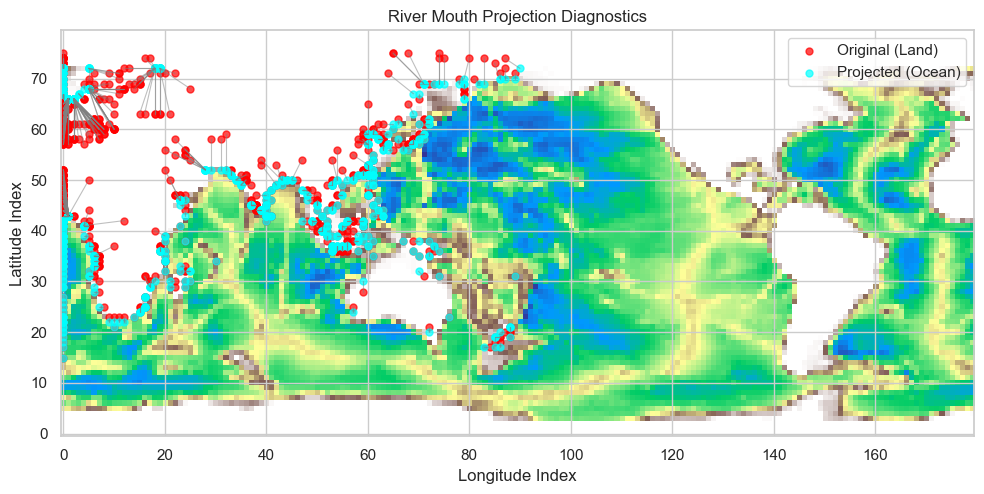

In [5]:
#!/usr/bin/env python3
"""
优化版微塑料初始场与RBCS文件生成脚本（带陆地投影优化与诊断可视化）

功能：
- 河口尽量保持原始位置
- 陆地/重叠河口投影到最近海洋格点
- 限制最大投影距离
- 使用log-uniform随机微扰
- 避免重复构建KDTree
- 输出诊断表与可视化河口位置对比图
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os


# ======================
# 参数与辅助函数
# ======================

def load_grid_info():
    nx, ny, nz = 180, 80, 40
    print(f"🌍 网格尺寸: {nx} x {ny} x {nz}")
    return nx, ny, nz


def create_coordinate_grid(nx, ny):
    lon = np.linspace(0, 360, nx, endpoint=False)
    lat = np.linspace(-80, 80, ny)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    return lon_grid, lat_grid, lon, lat


def load_topography():
    topo_file = 'input/ETOPO/topo.bin'
    nx, ny = 180, 80
    if os.path.exists(topo_file):
        with open(topo_file, 'rb') as f:
            topo = np.frombuffer(f.read(), dtype='>f4').reshape((ny, nx))
        print(f"✅ 地形数据加载成功，形状: {topo.shape}")
        return topo
    else:
        print("⚠️ 未找到地形文件，默认全部为海洋")
        return -np.ones((ny, nx))  # 全部为海洋


def load_river_data():
    df = pd.read_csv('river_emissions.csv')
    print(f"✅ 加载了 {len(df)} 条河流数据")
    return df


def build_ocean_kdtree(ocean_mask):
    """构建海洋格点KDTree（仅一次）"""
    ocean_points = np.array(np.where(ocean_mask)).T
    tree = cKDTree(ocean_points)
    return tree, ocean_points


def find_nearest_ocean_point(lat_idx, lon_idx, tree, ocean_points, max_radius=10):
    """找到最近的海洋格点，限制最大距离"""
    dist, idx = tree.query([lat_idx, lon_idx], k=1, distance_upper_bound=max_radius)
    if np.isinf(dist):
        return None, None, None
    new_lat_idx, new_lon_idx = ocean_points[idx]
    return int(new_lat_idx), int(new_lon_idx), float(dist)


def generate_initial_field(nx, ny, nz, topo):
    field = np.zeros((nz, ny, nx))
    ocean_mask = topo < 0
    field[0, ocean_mask] = 1e-6  # 海洋最低值
    print(f"✅ 初始场生成完成，非零数量: {np.count_nonzero(field)}")
    return field


# ======================
# RBCS 生成与日志记录
# ======================

def generate_rbcs(nx, ny, nz, river_df, topo):
    mask = np.zeros((nz, ny, nx))
    target = np.zeros((nz, ny, nx))
    ocean_mask = topo < 0
    occupied = []
    lat_vals = np.linspace(-80, 80, ny)
    lon_vals = np.linspace(0, 360, nx, endpoint=False)
    total_shift = 0.0
    max_radius = 10

    # 仅构建一次 KDTree
    tree, ocean_points = build_ocean_kdtree(ocean_mask)
    river_log = []

    for _, river in river_df.iterrows():
        lat_river = river['lat']
        lon_river = river['lon']
        emission_rate = river['Mid']

        lat_idx = np.argmin(np.abs(lat_vals - lat_river))
        lon_idx = np.argmin(np.abs(lon_vals - lon_river))

        new_lat_idx, new_lon_idx, shift = lat_idx, lon_idx, 0.0

        # 判断是否需要投影
        if (not ocean_mask[lat_idx, lon_idx]) or ((lat_idx, lon_idx) in occupied):
            new_lat_idx, new_lon_idx, shift = find_nearest_ocean_point(
                lat_idx, lon_idx, tree, ocean_points, max_radius=max_radius
            )
            if new_lat_idx is None:
                print(f"⚠️ 河口({lat_river:.2f}, {lon_river:.2f}) 在 {max_radius} 格点内无海洋，跳过")
                continue
            total_shift += shift

            # log-uniform 随机微扰 (小幅度)
            perturb_lat = int(np.clip(np.random.lognormal(mean=0, sigma=0.1) - 1, -1, 1))
            perturb_lon = int(np.clip(np.random.lognormal(mean=0, sigma=0.1) - 1, -1, 1))
            new_lat_idx = np.clip(new_lat_idx + perturb_lat, 0, ny - 1)
            new_lon_idx = np.clip(new_lon_idx + perturb_lon, 0, nx - 1)

        # 写入 mask 和 target
        mask[0, new_lat_idx, new_lon_idx] = 1.0
        target[0, new_lat_idx, new_lon_idx] += emission_rate
        occupied.append((new_lat_idx, new_lon_idx))

        river_log.append({
            'river_lat': lat_river,
            'river_lon': lon_river,
            'orig_lat_idx': lat_idx,
            'orig_lon_idx': lon_idx,
            'proj_lat_idx': new_lat_idx,
            'proj_lon_idx': new_lon_idx,
            'shift_grid': shift,
            'emission': emission_rate
        })

        print(f"✅ 河口({lat_river:.2f},{lon_river:.2f}) → 投影({new_lat_idx},{new_lon_idx}) 偏移 {shift:.2f} 格点")

    print(f"\n=== RBCS 统计 ===")
    print(f"RBCS mask 非零数量: {np.count_nonzero(mask)}")
    print(f"RBCS target 非零数量: {np.count_nonzero(target)}, 最大值: {np.max(target):.2e}")
    print(f"累计河口偏移格点距离: {total_shift:.2f}\n")

    river_log_df = pd.DataFrame(river_log)
    river_log_df.to_csv("river_projection_diagnostics.csv", index=False)
    print("💾 已保存投影诊断文件 → river_projection_diagnostics.csv")

    return mask, target, river_log_df


# ======================
# 可视化部分
# ======================

def visualize_river_projection(topo, river_log_df):
    plt.figure(figsize=(10, 5))
    plt.imshow(topo, cmap='terrain', origin='lower')
    plt.title("River Mouth Projection Diagnostics")
    plt.xlabel("Longitude Index")
    plt.ylabel("Latitude Index")

    # 原始河口位置（红色）
    plt.scatter(river_log_df["orig_lon_idx"], river_log_df["orig_lat_idx"],
                c='red', label='Original (Land)', s=25, alpha=0.7)

    # 投影后位置（青色）
    plt.scatter(river_log_df["proj_lon_idx"], river_log_df["proj_lat_idx"],
                c='cyan', label='Projected (Ocean)', s=25, alpha=0.7)

    # 连接线
    for _, row in river_log_df.iterrows():
        plt.plot([row["orig_lon_idx"], row["proj_lon_idx"]],
                 [row["orig_lat_idx"], row["proj_lat_idx"]],
                 color='gray', alpha=0.5, lw=0.8)

    plt.legend()
    plt.tight_layout()
    plt.show()


# ======================
# 主程序入口
# ======================

def save_binary_file(data, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'wb') as f:
        f.write(data.astype('>f4').tobytes())
    print(f"💾 保存 {filename}, 文件大小: {os.path.getsize(filename)} bytes")


def main():
    nx, ny, nz = load_grid_info()
    lon_grid, lat_grid, lon, lat = create_coordinate_grid(nx, ny)
    topo = load_topography()
    river_df = load_river_data()

    initial_field = generate_initial_field(nx, ny, nz, topo)
    rbcs_mask, rbcs_target, river_log_df = generate_rbcs(nx, ny, nz, river_df, topo)

    save_binary_file(initial_field, 'input/microplastic_initial.bin')
    save_binary_file(rbcs_mask, 'input/microplastic_rbcs_mask.bin')
    save_binary_file(rbcs_target, 'input/microplastic_rbcs_target.bin')

    visualize_river_projection(topo, river_log_df)


if __name__ == "__main__":
    main()


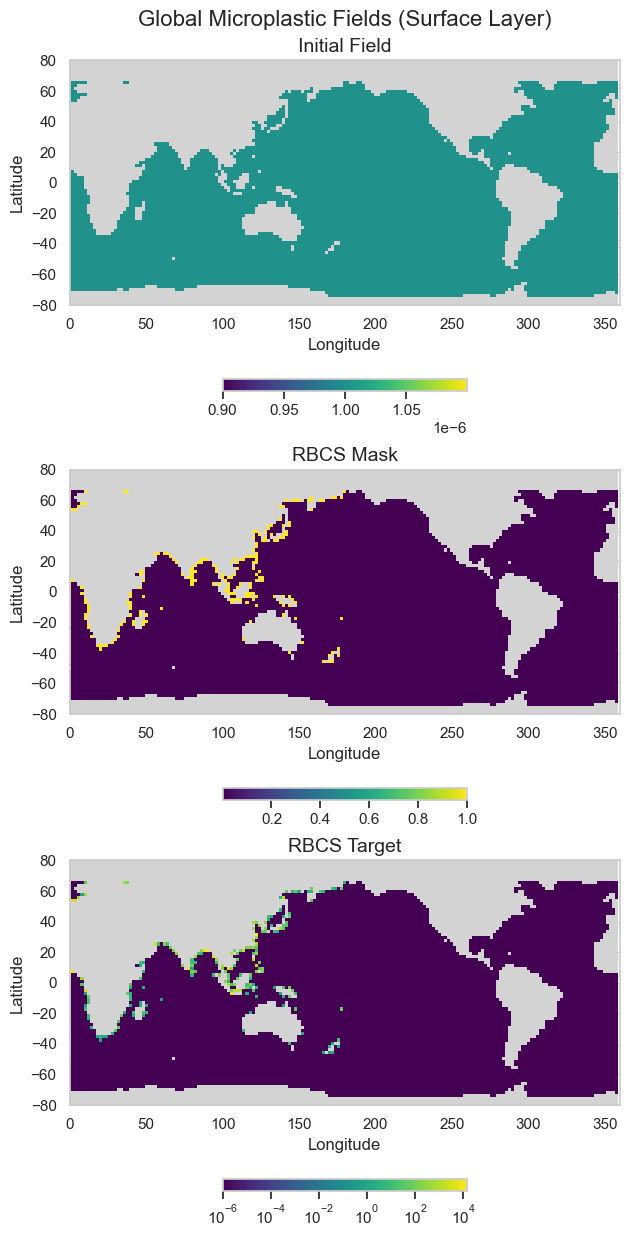

In [6]:
#!/usr/bin/env python3
"""
可视化微塑料初始场、RBCS mask和RBCS target
- 布局为 1 列 3 行
- 每张图保持标准世界地图比例
- 陆地显示为灰色
- RBCS target 使用对数色标显示，海洋最低值设为1e-6
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import warnings

warnings.filterwarnings("ignore")
sns.set(style='whitegrid')

# 文件路径
files = {
    'Initial Field': 'input/microplastic_initial.bin',
    'RBCS Mask': 'input/microplastic_rbcs_mask.bin',
    'RBCS Target': 'input/microplastic_rbcs_target.bin'
}

# 网格尺寸
nx, ny, nz = 180, 80, 40

# 经纬度
lon = np.linspace(0, 360, nx, endpoint=False)
lat = np.linspace(-80, 80, ny)

# 加载地形数据
topo_file = 'input/ETOPO/topo.bin'
if os.path.exists(topo_file):
    with open(topo_file, 'rb') as f:
        topo = np.frombuffer(f.read(), dtype='>f4').reshape((ny, nx))
else:
    topo = -np.ones((ny, nx))  # 全部为海洋

# 创建海洋掩码
ocean_mask = topo < 0

def read_bin(filename, shape):
    """读取big-endian float32二进制文件"""
    data = np.fromfile(filename, dtype='>f4')
    return data.reshape(shape)

# 创建 1 列 3 行图像
fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

for ax, (title, filepath) in zip(axes, files.items()):
    if os.path.exists(filepath):
        data = read_bin(filepath, (nz, ny, nx))
        surface = data[0, :, :].copy()

        # 陆地设为 NaN，海洋低值设为 1e-6
        surface[~ocean_mask] = np.nan
        surface[ocean_mask & (surface < 1e-6)] = 1e-6

        cmap = plt.cm.viridis
        cmap.set_bad(color='lightgray')  # 陆地灰色

        if title == 'RBCS Target':
            # 对数色标
            vmin, vmax = 1e-6, np.nanmax(surface)
            im = ax.pcolormesh(lon, lat, surface, cmap=cmap,
                               shading='auto',
                               norm=LogNorm(vmin=vmin, vmax=vmax))
        else:
            # 线性色标
            im = ax.pcolormesh(lon, lat, surface, cmap=cmap, shading='auto')

        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        ax.set_xlim(0, 360)
        ax.set_ylim(-80, 80)

        # 保持世界地图比例
        ax.set_aspect(1 / np.cos(np.deg2rad(lat.mean())))

        plt.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
    else:
        ax.text(0.5, 0.5, 'File not found', ha='center', va='center', fontsize=12)
        ax.set_title(title)

plt.suptitle('Global Microplastic Fields (Surface Layer)', fontsize=16, y=1.02)
plt.show()


选取的时间步索引: [ 0  7 14 21 29]
全局最大浓度 = 1.455e+04


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

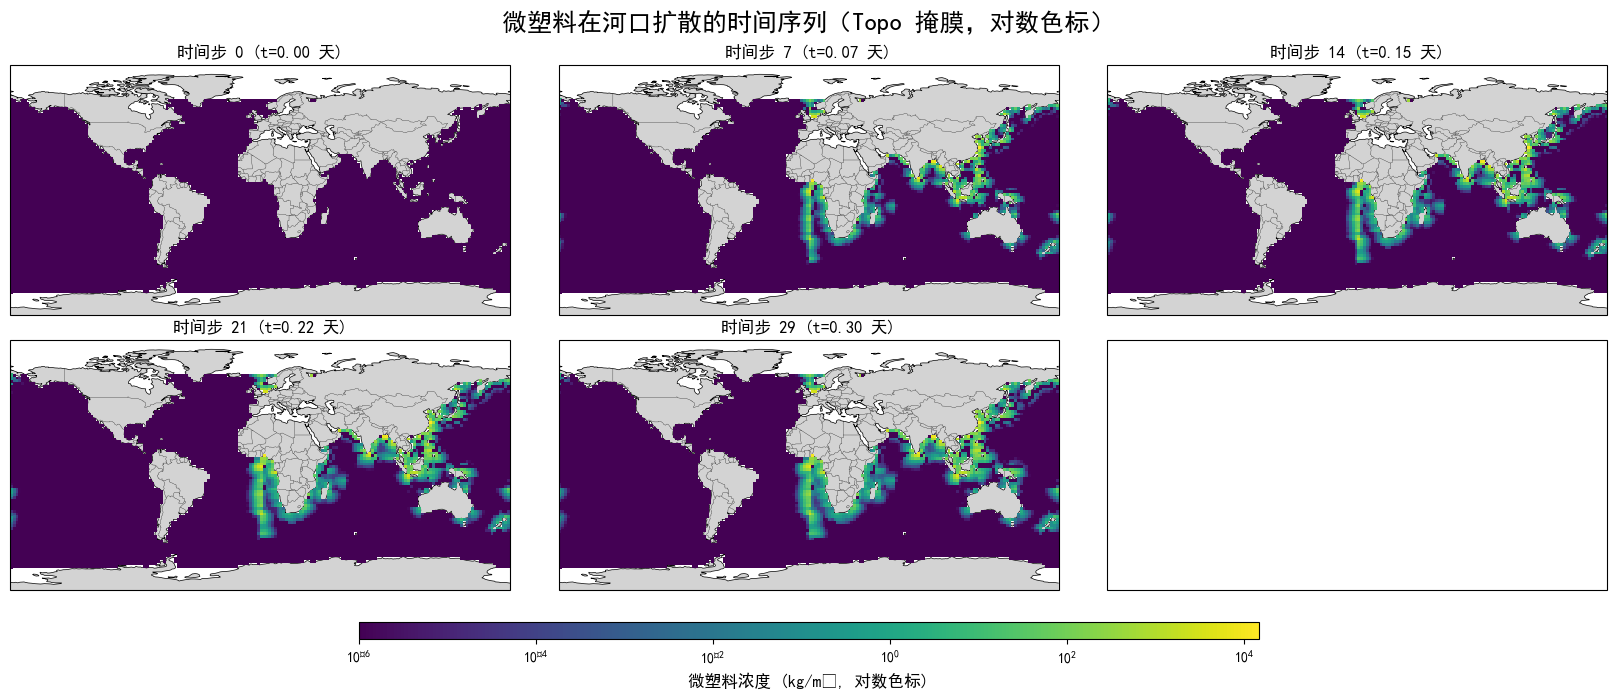

=== 对数色标绘图完成 ===


In [1]:
#!/usr/bin/env python3
"""
微塑料时间序列可视化（线性 + 对数色标）
- 均匀选取 5 帧 + 最后一帧
- 陆地显示灰色
- 对数色标最小值 1e-6
"""

import xmitgcm
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import os
import warnings
warnings.filterwarnings("ignore")



plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# === 加载 MITgcm 数据集 ===
ds = xmitgcm.open_mdsdataset(
    data_dir='./input/output/',
    grid_dir='./input/',
    prefix=['microplastics'],
    delta_t=900
)

# === 模型时间参数 ===
dt = 900
seconds_per_day = 86400
n_total = len(ds.time)
n_frames = 5

# 均匀选取时间步索引 (0-based)
time_steps = np.linspace(0, n_total-1, n_frames, dtype=int)
if (n_total-1) not in time_steps:
    time_steps = np.append(time_steps, n_total-1)
print("选取的时间步索引:", time_steps)

# === 经纬网格 ===
lon_grid, lat_grid = np.meshgrid(ds.XC, ds.YC)

# === 读取 topo.bin 生成海洋掩膜 ===
topo_file = './input/ETOPO/topo.bin'
nx, ny = ds.dims['XC'], ds.dims['YC']
with open(topo_file, 'rb') as f:
    topo = np.frombuffer(f.read(), dtype='>f4').reshape((ny, nx))
ocean_mask = topo < 0  # 海洋 = True, 陆地 = False

# === 全局最大值（对数色标） ===
max_conc = 0
for t_idx in time_steps:
    mp_data = ds.TRAC01.isel(time=t_idx, Z=0)
    current_max = float(mp_data.max().compute())
    max_conc = max(max_conc, current_max)
print(f"全局最大浓度 = {max_conc:.3e}")

# === 绘制对数色标图 ===
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, t_idx in enumerate(time_steps):
    ax = axes[i]
    ax.set_global()
    ax.coastlines(linewidth=0.5, color='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    mp_data = ds.TRAC01.isel(time=t_idx, Z=0)
    mp_plot = np.where(ocean_mask, mp_data, np.nan)

    # 对数色标，最小值固定为 1e-6
    mp_plot_log = mp_plot.copy()
    mp_plot_log[mp_plot_log < 1e-6] = 1e-6  # 避免 log(0)
    im = ax.pcolormesh(
        lon_grid, lat_grid, mp_plot_log,
        cmap='viridis',
        norm=LogNorm(vmin=1e-6, vmax=max_conc),
        shading='auto',
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    time_days = t_idx * dt / seconds_per_day
    ax.set_title(f'时间步 {t_idx} (t={time_days:.2f} 天)', fontsize=12)
    ax.tick_params(labelsize=9)

# 色条
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('微塑料浓度 (kg/m³, 对数色标)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

fig.suptitle('微塑料在河口扩散的时间序列（Topo 掩膜，对数色标）', fontsize=18, y=0.98)
plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.15,
                    wspace=0.05, hspace=0.1)

plt.savefig('microplastic_diffusion_timeseries_log_topo.png', dpi=600, bbox_inches='tight')
plt.show()

print("=== 对数色标绘图完成 ===")


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

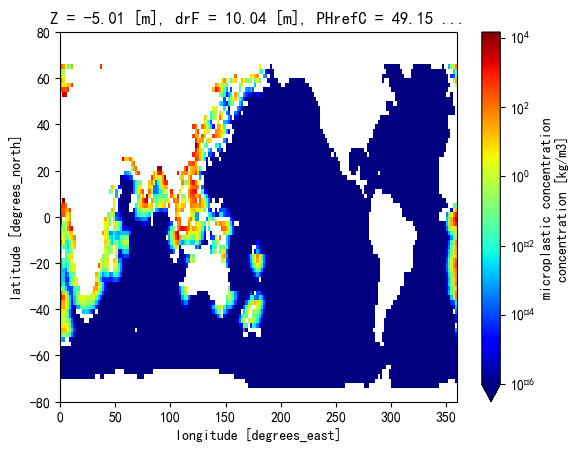

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

vmax = float(ds.TRAC01.max().compute())  # 计算最大值为标量
vmin = 1e-6                              # 设定非零下限

ds.TRAC01.where(ds.TRAC01 != 0)[-1, 0].plot(
    cmap='jet',
    norm=colors.LogNorm(vmin=vmin, vmax=vmax)
)
plt.show()
